# Empirical Performance Analysis - Right Censored (RC) Case

This notebook analyzes the empirical performance of density and survival estimates for the RC case.
The focus is on **oracle coverage** (not delta method CI coverage), along with bias, variance, and MSE metrics.

**Note:** Analysis is restricted to the **inner 99% range** of the true distribution [0.242, 0.758] to avoid tail regions where sparse observations can cause estimation issues.

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

# Define path to data
script_dir = os.getcwd()
folder_path = os.path.join(script_dir, 'Asymptoticity_RC_0301', 'out')
output_folder = os.path.join(script_dir, 'Empirical_Performance_Results', 'RC')

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

print(f"Data folder: {folder_path}")
print(f"Output folder: {output_folder}")
print(f"Folder exists: {os.path.exists(folder_path)}")

Data folder: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Asymptoticity_RC_0301/out
Output folder: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Empirical_Performance_Results/RC
Folder exists: True


## Helper Functions

In [2]:
# True density and survival functions (truncated normal)
def compute_true_density(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """Compute true density for truncated normal distribution"""
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.pdf(grid_points, a, b, loc=mean, scale=std)

def compute_true_survival(grid_points, mean=0.5, std=0.1, lower=0, upper=1):
    """Compute true survival function for truncated normal distribution"""
    a, b = (lower - mean) / std, (upper - mean) / std
    return truncnorm.sf(grid_points, a, b, loc=mean, scale=std)

def get_inner_99_range(mean=0.5, std=0.1, lower=0, upper=1):
    """Get the inner 99% range of the true distribution"""
    a, b = (lower - mean) / std, (upper - mean) / std
    dist = truncnorm(a, b, loc=mean, scale=std)
    return dist.ppf(0.005), dist.ppf(0.995)

def extract_sample_size_and_smooth(filename):
    """Extract sample size and smooth order from filename"""
    match = re.search(r"hal_n(\d+)_smooth(\d+)_", filename)
    if match:
        return int(match.group(1)), int(match.group(2))
    return None, None

def compute_empirical_metrics(estimates_df, true_values, eval_points, inner_99_range):
    """
    Compute empirical performance metrics for evaluation points within inner 99% range.
    
    Returns dictionary with:
    - mean: mean of estimates across simulations
    - bias: mean - true_value
    - variance: variance across simulations
    - mse: mean squared error
    - oracle_coverage: coverage using oracle standard error
    """
    # Filter to inner 99% range
    lower_bound, upper_bound = inner_99_range
    mask = (eval_points >= lower_bound) & (eval_points <= upper_bound)
    
    filtered_indices = np.where(mask)[0]
    n_eval = len(filtered_indices)
    
    results = {
        'mean': [],
        'bias': [],
        'variance': [],
        'mse': [],
        'oracle_coverage': [],
        'eval_points_used': eval_points[mask],
        'n_eval_points': n_eval
    }
    
    for i in filtered_indices:
        # Get estimates across all simulations for this eval point
        est_values = estimates_df.iloc[i, 1:].astype(float).values
        true_val = true_values[i]
        
        # Compute metrics
        mean_est = np.mean(est_values)
        bias = mean_est - true_val
        variance = np.var(est_values, ddof=1)
        mse = np.mean((est_values - true_val)**2)
        
        # Oracle coverage: use sample std as oracle SE
        oracle_se = np.std(est_values, ddof=1)
        lower_bounds = est_values - 1.96 * oracle_se
        upper_bounds = est_values + 1.96 * oracle_se
        oracle_cov = np.mean((true_val >= lower_bounds) & (true_val <= upper_bounds)) * 100
        
        results['mean'].append(mean_est)
        results['bias'].append(bias)
        results['variance'].append(variance)
        results['mse'].append(mse)
        results['oracle_coverage'].append(oracle_cov)
    
    return results

# Get inner 99% range
inner_99_range = get_inner_99_range()
print(f"\nInner 99% range: [{inner_99_range[0]:.6f}, {inner_99_range[1]:.6f}]")
print(f"Analysis will be restricted to evaluation points within this range.")


Inner 99% range: [0.242419, 0.757581]
Analysis will be restricted to evaluation points within this range.


## Part 1: Density Estimates - Empirical Performance

In [3]:
# Get all final density files
density_files = glob.glob(os.path.join(folder_path, "*final_density.csv"))
print(f"Found {len(density_files)} density files")

# Dictionary to store results by (n_samples, smooth_order)
density_results = {}

for density_file in sorted(density_files):
    basename = os.path.basename(density_file)
    n_samples, smooth_order = extract_sample_size_and_smooth(basename)
    
    if n_samples is None:
        continue
    
    # Read density estimates
    density_df = pd.read_csv(density_file)
    eval_points = density_df.iloc[:, 0].values
    true_density = compute_true_density(eval_points)
    
    # Compute empirical metrics (filtered to inner 99%)
    metrics = compute_empirical_metrics(density_df, true_density, eval_points, inner_99_range)
    
    # Store results
    key = (n_samples, smooth_order)
    density_results[key] = {
        'true_values': true_density,
        **metrics
    }
    
    print(f"Processed: n={n_samples}, smooth={smooth_order}, eval_points_in_range={metrics['n_eval_points']}")

print(f"\nTotal configurations processed: {len(density_results)}")

Found 10 density files
Processed: n=1600, smooth=0, eval_points_in_range=10
Processed: n=1600, smooth=1, eval_points_in_range=10
Processed: n=200, smooth=0, eval_points_in_range=10
Processed: n=200, smooth=1, eval_points_in_range=10
Processed: n=3200, smooth=0, eval_points_in_range=10
Processed: n=3200, smooth=1, eval_points_in_range=10
Processed: n=400, smooth=0, eval_points_in_range=10
Processed: n=400, smooth=1, eval_points_in_range=10
Processed: n=800, smooth=0, eval_points_in_range=10
Processed: n=800, smooth=1, eval_points_in_range=10

Total configurations processed: 10


### Table 1: Density Estimates - Summary Statistics by Sample Size and Smooth Order

In [4]:
# Create summary table for density estimates
summary_rows = []

for (n_samples, smooth_order), results in sorted(density_results.items()):
    row = {
        'Sample Size': n_samples,
        'Smooth Order': smooth_order,
        'N Eval Points': results['n_eval_points'],
        'Mean Abs Bias': np.mean(np.abs(results['bias'])),
        'Mean Variance': np.mean(results['variance']),
        'Mean MSE': np.mean(results['mse']),
        'Median Oracle Coverage (%)': np.median(results['oracle_coverage']),
        'Mean Oracle Coverage (%)': np.mean(results['oracle_coverage'])
    }
    summary_rows.append(row)

density_summary_table = pd.DataFrame(summary_rows)

print("\n" + "="*90)
print("DENSITY ESTIMATES - EMPIRICAL PERFORMANCE SUMMARY (RC Case)")
print(f"Evaluation restricted to inner 99% range: [{inner_99_range[0]:.3f}, {inner_99_range[1]:.3f}]")
print("="*90)
print(density_summary_table.to_string(index=False))
print("="*90)

# Save to CSV in output folder
output_file = os.path.join(output_folder, 'RC_Density_Empirical_Performance_Summary.csv')
density_summary_table.to_csv(output_file, index=False)
print(f"\nTable saved to: {output_file}")


DENSITY ESTIMATES - EMPIRICAL PERFORMANCE SUMMARY (RC Case)
Evaluation restricted to inner 99% range: [0.242, 0.758]
 Sample Size  Smooth Order  N Eval Points  Mean Abs Bias  Mean Variance  Mean MSE  Median Oracle Coverage (%)  Mean Oracle Coverage (%)
         200             0             10       0.068803       1.174912  1.179305                        96.6                     96.56
         200             1             10       0.033285       0.259860  0.260722                        94.7                     94.60
         400             0             10       0.050258       0.528175  0.530746                        96.3                     96.20
         400             1             10       0.017443       0.138789  0.138939                        94.4                     94.64
         800             0             10       0.043862       0.253000  0.254989                        95.1                     95.24
         800             1             10       0.011092       0.0

### Visualization: Density Performance by Sample Size (for each Smooth Order)

/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])


Saved plot: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Empirical_Performance_Results/RC/RC_Density_Performance_Smooth0.png


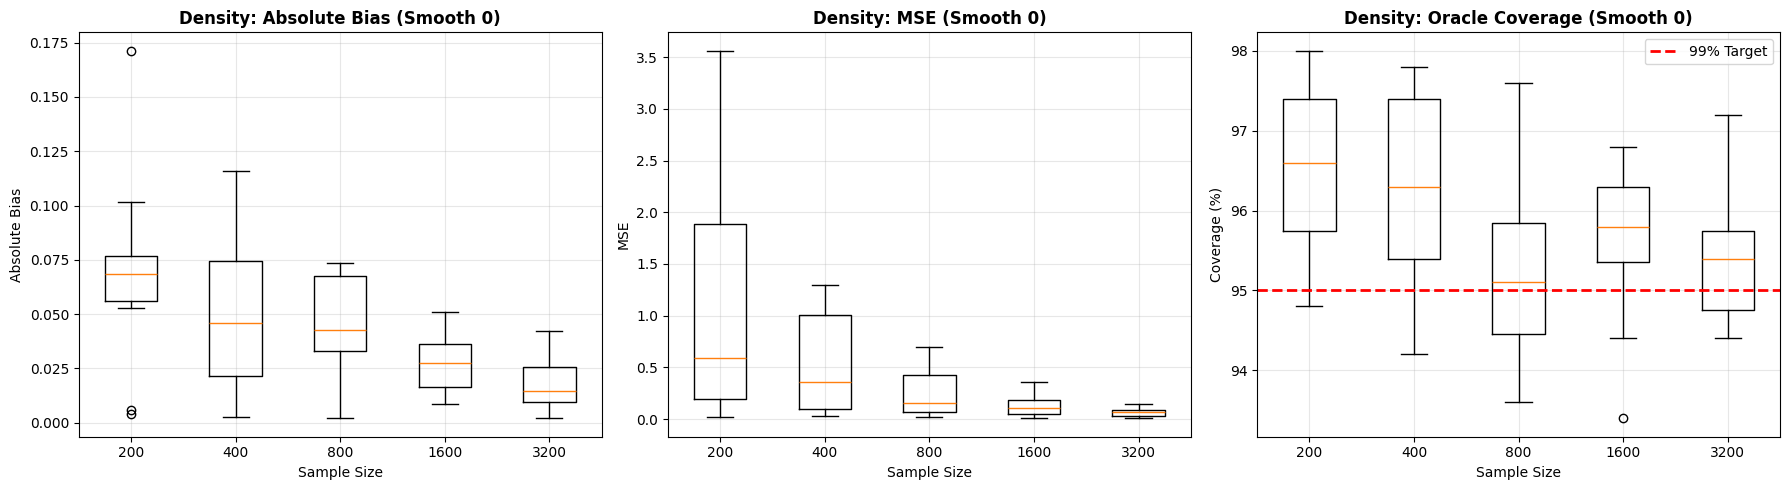

/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/1953662727.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])


Saved plot: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Empirical_Performance_Results/RC/RC_Density_Performance_Smooth1.png


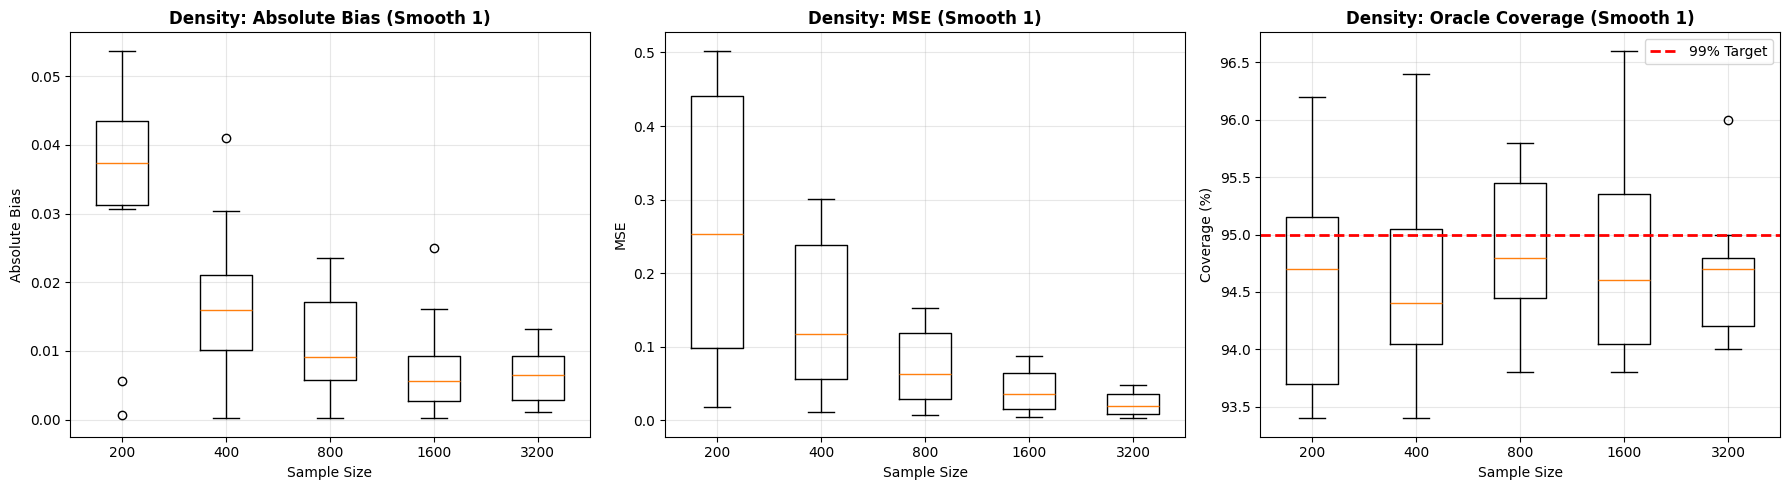

In [5]:
# Group by smooth order
smooth_orders = sorted(set(s for (n, s) in density_results.keys()))

for smooth in smooth_orders:
    # Filter for this smooth order
    filtered_keys = sorted([(n, s) for (n, s) in density_results.keys() if s == smooth])
    sample_sizes = [n for (n, s) in filtered_keys]
    
    # Prepare data for plotting
    bias_data = [np.abs(density_results[(n, smooth)]['bias']) for n in sample_sizes]
    mse_data = [density_results[(n, smooth)]['mse'] for n in sample_sizes]
    coverage_data = [density_results[(n, smooth)]['oracle_coverage'] for n in sample_sizes]
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bias boxplot
    axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
    axes[0].set_title(f'Density: Absolute Bias (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Sample Size')
    axes[0].set_ylabel('Absolute Bias')
    axes[0].grid(True, alpha=0.3)
    
    # MSE boxplot
    axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
    axes[1].set_title(f'Density: MSE (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Size')
    axes[1].set_ylabel('MSE')
    axes[1].grid(True, alpha=0.3)
    
    # Oracle coverage boxplot
    axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])
    axes[2].axhline(y=95, color='red', linestyle='--', linewidth=2, label='99% Target')
    axes[2].set_title(f'Density: Oracle Coverage (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Sample Size')
    axes[2].set_ylabel('Coverage (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_file = os.path.join(output_folder, f'RC_Density_Performance_Smooth{smooth}.png')
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"Saved plot: {plot_file}")
    plt.show()

## Part 2: Survival Estimates - Empirical Performance

In [6]:
# Get all final survival files
survival_files = glob.glob(os.path.join(folder_path, "*final_survival.csv"))
print(f"Found {len(survival_files)} survival files")

# Dictionary to store results by (n_samples, smooth_order)
survival_results = {}

for survival_file in sorted(survival_files):
    basename = os.path.basename(survival_file)
    n_samples, smooth_order = extract_sample_size_and_smooth(basename)
    
    if n_samples is None:
        continue
    
    # Read survival estimates
    survival_df = pd.read_csv(survival_file)
    eval_points = survival_df.iloc[:, 0].values
    true_survival = compute_true_survival(eval_points)
    
    # Compute empirical metrics (filtered to inner 99%)
    metrics = compute_empirical_metrics(survival_df, true_survival, eval_points, inner_99_range)
    
    # Store results
    key = (n_samples, smooth_order)
    survival_results[key] = {
        'true_values': true_survival,
        **metrics
    }
    
    print(f"Processed: n={n_samples}, smooth={smooth_order}, eval_points_in_range={metrics['n_eval_points']}")

print(f"\nTotal configurations processed: {len(survival_results)}")

Found 10 survival files
Processed: n=1600, smooth=0, eval_points_in_range=10
Processed: n=1600, smooth=1, eval_points_in_range=10
Processed: n=200, smooth=0, eval_points_in_range=10
Processed: n=200, smooth=1, eval_points_in_range=10
Processed: n=3200, smooth=0, eval_points_in_range=10
Processed: n=3200, smooth=1, eval_points_in_range=10
Processed: n=400, smooth=0, eval_points_in_range=10
Processed: n=400, smooth=1, eval_points_in_range=10
Processed: n=800, smooth=0, eval_points_in_range=10
Processed: n=800, smooth=1, eval_points_in_range=10

Total configurations processed: 10


### Table 2: Survival Estimates - Summary Statistics by Sample Size and Smooth Order

In [7]:
# Create summary table for survival estimates
summary_rows = []

for (n_samples, smooth_order), results in sorted(survival_results.items()):
    row = {
        'Sample Size': n_samples,
        'Smooth Order': smooth_order,
        'N Eval Points': results['n_eval_points'],
        'Mean Abs Bias': np.mean(np.abs(results['bias'])),
        'Mean Variance': np.mean(results['variance']),
        'Mean MSE': np.mean(results['mse']),
        'Median Oracle Coverage (%)': np.median(results['oracle_coverage']),
        'Mean Oracle Coverage (%)': np.mean(results['oracle_coverage'])
    }
    summary_rows.append(row)

survival_summary_table = pd.DataFrame(summary_rows)

print("\n" + "="*90)
print("SURVIVAL ESTIMATES - EMPIRICAL PERFORMANCE SUMMARY (RC Case)")
print(f"Evaluation restricted to inner 99% range: [{inner_99_range[0]:.3f}, {inner_99_range[1]:.3f}]")
print("="*90)
print(survival_summary_table.to_string(index=False))
print("="*90)

# Save to CSV in output folder
output_file = os.path.join(output_folder, 'RC_Survival_Empirical_Performance_Summary.csv')
survival_summary_table.to_csv(output_file, index=False)
print(f"\nTable saved to: {output_file}")


SURVIVAL ESTIMATES - EMPIRICAL PERFORMANCE SUMMARY (RC Case)
Evaluation restricted to inner 99% range: [0.242, 0.758]
 Sample Size  Smooth Order  N Eval Points  Mean Abs Bias  Mean Variance  Mean MSE  Median Oracle Coverage (%)  Mean Oracle Coverage (%)
         200             0             10       0.005469       0.001038  0.001074                        94.8                     93.66
         200             1             10       0.001819       0.000916  0.000918                        95.2                     95.34
         400             0             10       0.002978       0.000500  0.000511                        95.0                     94.82
         400             1             10       0.001100       0.000442  0.000443                        95.5                     95.32
         800             0             10       0.002464       0.000240  0.000247                        94.6                     94.74
         800             1             10       0.000531       0.

### Visualization: Survival Performance by Sample Size (for each Smooth Order)

/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])


Saved plot: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Empirical_Performance_Results/RC/RC_Survival_Performance_Smooth0.png


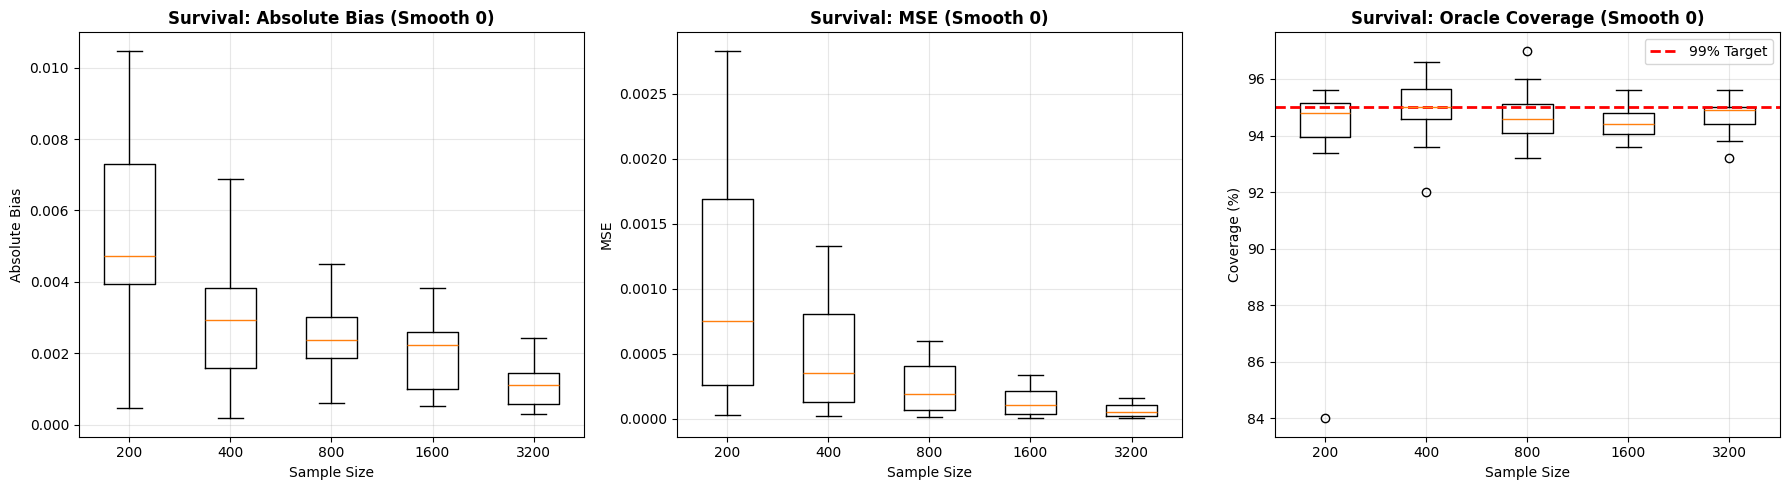

/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
/var/folders/s9/cp67nwl1685gb_f0prtd64sm0000gn/T/ipykernel_82420/229848325.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])


Saved plot: /Users/liyi/Documents/GitHub/Ch7_EM_HAL/EM_HAL_1D/Empirical_Performance_Results/RC/RC_Survival_Performance_Smooth1.png


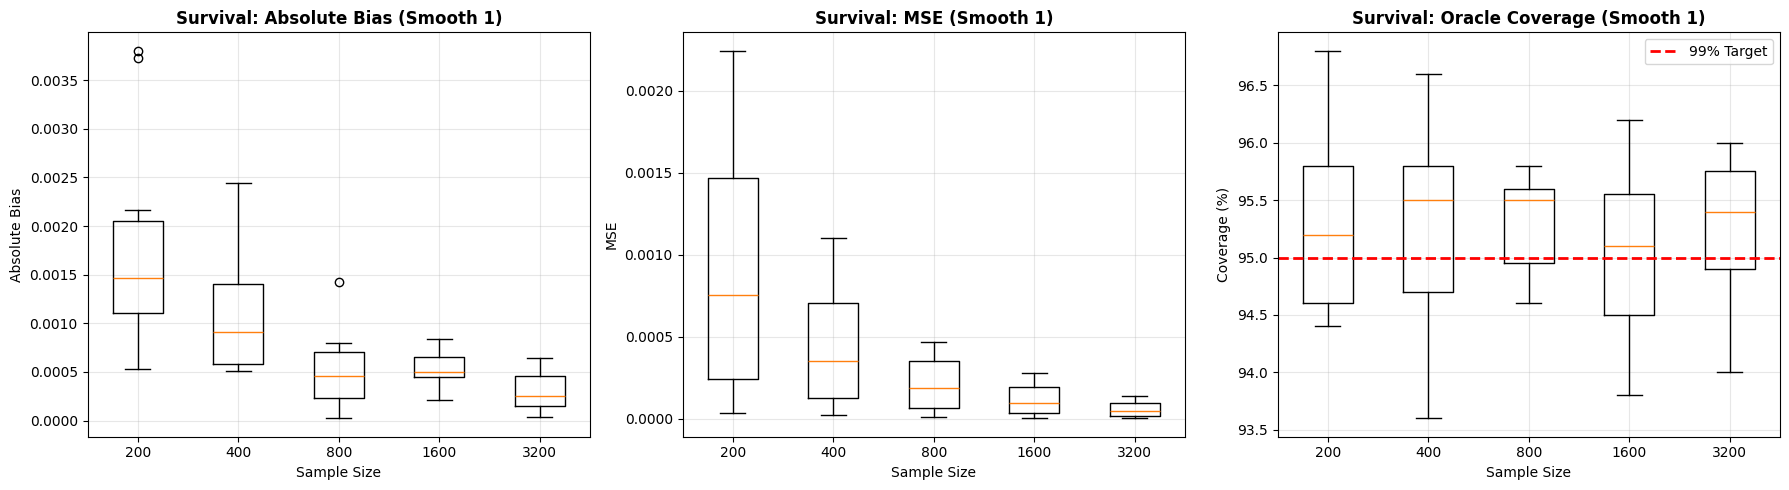

In [8]:
# Group by smooth order
smooth_orders = sorted(set(s for (n, s) in survival_results.keys()))

for smooth in smooth_orders:
    # Filter for this smooth order
    filtered_keys = sorted([(n, s) for (n, s) in survival_results.keys() if s == smooth])
    sample_sizes = [n for (n, s) in filtered_keys]
    
    # Prepare data for plotting
    bias_data = [np.abs(survival_results[(n, smooth)]['bias']) for n in sample_sizes]
    mse_data = [survival_results[(n, smooth)]['mse'] for n in sample_sizes]
    coverage_data = [survival_results[(n, smooth)]['oracle_coverage'] for n in sample_sizes]
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bias boxplot
    axes[0].boxplot(bias_data, labels=[str(n) for n in sample_sizes])
    axes[0].set_title(f'Survival: Absolute Bias (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Sample Size')
    axes[0].set_ylabel('Absolute Bias')
    axes[0].grid(True, alpha=0.3)
    
    # MSE boxplot
    axes[1].boxplot(mse_data, labels=[str(n) for n in sample_sizes])
    axes[1].set_title(f'Survival: MSE (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Sample Size')
    axes[1].set_ylabel('MSE')
    axes[1].grid(True, alpha=0.3)
    
    # Oracle coverage boxplot
    axes[2].boxplot(coverage_data, labels=[str(n) for n in sample_sizes])
    axes[2].axhline(y=95, color='red', linestyle='--', linewidth=2, label='99% Target')
    axes[2].set_title(f'Survival: Oracle Coverage (Smooth {smooth})', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Sample Size')
    axes[2].set_ylabel('Coverage (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plot_file = os.path.join(output_folder, f'RC_Survival_Performance_Smooth{smooth}.png')
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    print(f"Saved plot: {plot_file}")
    plt.show()

## Part 3: Combined Summary Table

In [9]:
# Merge density and survival tables for side-by-side comparison
density_summary_table['Estimate Type'] = 'Density'
survival_summary_table['Estimate Type'] = 'Survival'

combined_table = pd.concat([density_summary_table, survival_summary_table], ignore_index=True)
combined_table = combined_table[['Estimate Type', 'Sample Size', 'Smooth Order', 'N Eval Points',
                                   'Mean Abs Bias', 'Mean Variance', 'Mean MSE', 
                                   'Median Oracle Coverage (%)', 'Mean Oracle Coverage (%)']]

print("\n" + "="*110)
print("COMBINED EMPIRICAL PERFORMANCE SUMMARY - RC Case")
print(f"Evaluation restricted to inner 99% range: [{inner_99_range[0]:.3f}, {inner_99_range[1]:.3f}]")
print("="*110)
print(combined_table.to_string(index=False))
print("="*110)

output_file = os.path.join(output_folder, 'RC_Combined_Empirical_Performance_Summary.csv')
combined_table.to_csv(output_file, index=False)
print(f"\nCombined table saved to: {output_file}")
print(f"\nAll results saved to folder: {output_folder}")


COMBINED EMPIRICAL PERFORMANCE SUMMARY - RC Case
Evaluation restricted to inner 99% range: [0.242, 0.758]
Estimate Type  Sample Size  Smooth Order  N Eval Points  Mean Abs Bias  Mean Variance  Mean MSE  Median Oracle Coverage (%)  Mean Oracle Coverage (%)
      Density          200             0             10       0.068803       1.174912  1.179305                        96.6                     96.56
      Density          200             1             10       0.033285       0.259860  0.260722                        94.7                     94.60
      Density          400             0             10       0.050258       0.528175  0.530746                        96.3                     96.20
      Density          400             1             10       0.017443       0.138789  0.138939                        94.4                     94.64
      Density          800             0             10       0.043862       0.253000  0.254989                        95.1                    